# BAGIAN 1 — IMPORT LIBRARY

Pada kesempatan ini, saya akan mempresentasikan proyek Ujian Akhir Semester Bengkel Koding Data Science yang berfokus pada prediksi churn pelanggan pada industri telekomunikasi menggunakan pendekatan machine learning dan deployment aplikasi berbasis web menggunakan Streamlit.

Churn pelanggan merupakan kondisi ketika pelanggan berhenti menggunakan layanan perusahaan. Dalam industri telekomunikasi, churn menjadi masalah penting karena kehilangan pelanggan berdampak langsung terhadap penurunan pendapatan, sementara biaya untuk mendapatkan pelanggan baru relatif lebih tinggi dibandingkan mempertahankan pelanggan lama.

Oleh karena itu, dibutuhkan sebuah sistem yang mampu memprediksi pelanggan yang berpotensi churn sejak dini, sehingga perusahaan dapat melakukan strategi retensi secara lebih efektif dan tepat sasaran.

Proyek ini bertujuan untuk membangun sistem prediksi churn pelanggan Telco menggunakan machine learning. Dataset yang digunakan berisi 7.043 data pelanggan dengan target Churn. Saya melakukan EDA, membangun beberapa model dari tiga kategori, mengevaluasi performanya dalam tiga skenario, kemudian mendeploy model terbaik ke Streamlit Cloud agar dapat digunakan secara real-time.

In [ ]:
# =========================
# 1. IMPORT LIBRARY
# =========================

# Manipulasi data
import pandas as pd
import numpy as np

# Visualisasi data
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Model konvensional
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

# Model ensemble
from sklearn.ensemble import RandomForestClassifier, VotingClassifier

# Evaluasi model
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# Menyimpan model
import joblib


# BAGIAN 2 — LOAD DATASET

Dataset yang digunakan pada proyek ini adalah Telco Customer Churn Dataset yang berisi 7.043 data pelanggan dengan berbagai fitur, seperti:

Data demografis pelanggan

Jenis layanan yang digunakan

Lama berlangganan (tenure)

Informasi tagihan dan metode pembayaran

Target dari dataset ini adalah variabel Churn, yang menunjukkan apakah pelanggan berhenti berlangganan atau tidak.

Adapun tujuan utama proyek ini adalah:

Melakukan Exploratory Data Analysis (EDA) untuk memahami karakteristik data.

Membangun dan membandingkan beberapa model machine learning.

Mengevaluasi performa model dalam tiga skenario berbeda.

Menentukan model terbaik berdasarkan metrik evaluasi.

Melakukan deployment model ke aplikasi web interaktif menggunakan Streamlit Cloud.

In [82]:
# =========================
# 2. LOAD DATASET
# =========================

# Membaca dataset Telco Customer Churn
df = pd.read_csv("Telco-Customer-Churn.csv")



In [83]:
# Menampilkan 5 data teratas
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


# BAGIAN 3 — EDA (Exploratory Data Analysis)

In [84]:
# Menampilkan struktur data
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [85]:
# Menampilkan statistik deskriptif
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [86]:
# Menghitung persentase missing value
missing_percent = df.isnull().mean() * 100

# Ambil kolom yang benar-benar memiliki missing value
cols_with_missing = missing_percent[missing_percent > 0]

plt.figure(figsize=(10,4))
if not cols_with_missing.empty:
    cols_with_missing.plot(kind='bar')
    plt.title("Persentase Missing Value")
    plt.ylabel("Persentase (%)")
    plt.show()
else:
    print("Tidak ada missing value eksplisit di dataset.")
    plt.close()


Tidak ada missing value eksplisit di dataset.


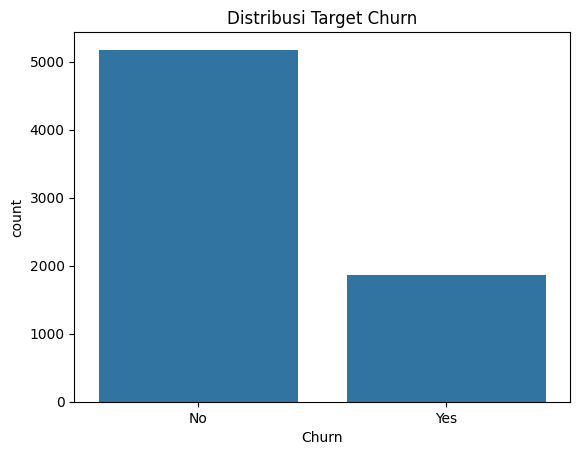

In [87]:
# Visualisasi distribusi target
sns.countplot(x='Churn', data=df)
plt.title("Distribusi Target Churn")
plt.show()

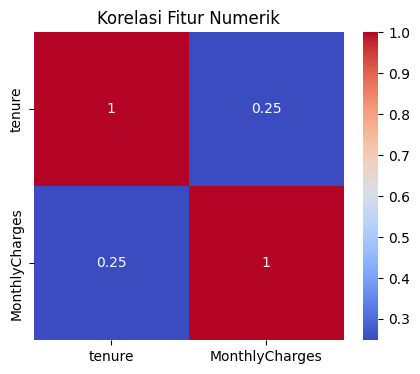

In [88]:
# Memilih fitur numerik
numeric_cols = ['tenure', 'MonthlyCharges']

plt.figure(figsize=(5,4))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm')
plt.title("Korelasi Fitur Numerik")
plt.show()


# BAGIAN 4 — PREPROCESSING DATA (WAJIB SEBELUM SPLIT)

4️⃣ PREPROCESSING DATA

Tahap preprocessing merupakan tahap yang sangat krusial pada proyek ini.

Salah satu tantangan utama adalah pada kolom TotalCharges, di mana nilai kosong tidak ditandai sebagai missing value, melainkan berupa spasi kosong. Oleh karena itu, dilakukan langkah-langkah berikut:

Mengganti spasi kosong dengan nilai NaN

Mengonversi TotalCharges ke tipe numerik

Menghapus baris data yang masih mengandung nilai kosong

Menghapus kolom customerID karena tidak memiliki pengaruh terhadap churn

Selain itu, dilakukan pemisahan fitur numerik dan kategorikal, kemudian dilakukan:

StandardScaler untuk fitur numerik

One-Hot Encoding untuk fitur kategorikal

Seluruh proses preprocessing ini dimasukkan ke dalam pipeline agar konsisten saat training dan deployment.

In [1]:
# =========================
# 4. PREPROCESSING
# =========================

# Copy dataset agar aman
df_clean = df.copy()

# Mengganti spasi kosong dengan NaN
df_clean['TotalCharges'] = df_clean['TotalCharges'].replace(" ", np.nan)

# Mengubah TotalCharges ke numerik
df_clean['TotalCharges'] = pd.to_numeric(df_clean['TotalCharges'])

# Menghapus baris yang masih memiliki NaN
df_clean = df_clean.dropna()

# Menghapus kolom ID karena tidak berpengaruh pada churn
df_clean = df_clean.drop(columns=['customerID'])


NameError: name 'df' is not defined

# BAGIAN 5 — MENENTUKAN X & y

In [90]:
# Fitur prediktor
X = df_clean.drop(columns=['Churn'])

# Target
y = df_clean['Churn'].map({'Yes': 1, 'No': 0})


# BAGIAN 6 — TRAIN TEST SPLIT

In [91]:
# Membagi data menjadi 80% train dan 20% test
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


# BAGIAN 7 — PIPELINE PREPROCESSING

In [92]:
# Kolom numerik dan kategorikal
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
cat_cols = X_train.drop(columns=num_cols).columns

# Pipeline preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
    ]
)


# BAGIAN 8 — MODELING TANPA TUNING

5️⃣ MODELING & SKENARIO EKSPERIMEN

Pada proyek ini, saya melakukan eksperimen dalam tiga skenario utama.

🔹 Skenario 1 – Direct Modeling

Model dilatih langsung tanpa preprocessing.
Hasilnya menunjukkan performa yang kurang optimal karena data belum siap digunakan oleh algoritma machine learning.

🔹 Skenario 2 – Modeling dengan Preprocessing

Model dilatih menggunakan pipeline preprocessing.
Pada skenario ini, performa model meningkat secara signifikan karena data sudah berada dalam format yang sesuai.

🔹 Skenario 3 – Hyperparameter Tuning

Pada skenario terakhir, dilakukan GridSearchCV untuk mengoptimalkan parameter model.

In [93]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(random_state=42),
    "Voting Classifier": VotingClassifier(
        estimators=[
            ('lr', LogisticRegression(max_iter=1000)),
            ('svm', SVC(probability=True)),
            ('knn', KNeighborsClassifier())
        ],
        voting='soft'
    )
}

for name, model in models.items():
    pipe = Pipeline([
        ('prep', preprocessor),
        ('model', model)
    ])

    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)

    print(f"Model: {name}")
    print("Accuracy :", accuracy_score(y_test, y_pred))
    print("Precision:", precision_score(y_test, y_pred))
    print("Recall   :", recall_score(y_test, y_pred))
    print("F1-score :", f1_score(y_test, y_pred))
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
    print("-"*50)


Model: Logistic Regression
Accuracy : 0.8045486851457001
Precision: 0.649546827794562
Recall   : 0.5748663101604278
F1-score : 0.6099290780141844
Confusion Matrix:
 [[917 116]
 [159 215]]
--------------------------------------------------
Model: Random Forest
Accuracy : 0.7860696517412935
Precision: 0.6196721311475409
Recall   : 0.5053475935828877
F1-score : 0.5567010309278351
Confusion Matrix:
 [[917 116]
 [185 189]]
--------------------------------------------------
Model: Voting Classifier
Accuracy : 0.7924662402274343
Precision: 0.6305732484076433
Recall   : 0.5294117647058824
F1-score : 0.5755813953488372
Confusion Matrix:
 [[917 116]
 [176 198]]
--------------------------------------------------


# BAGIAN 9 — HYPERPARAMETER TUNING (MODEL TERBAIK)

6️⃣ MODEL YANG DIGUNAKAN

Saya menggunakan tiga kategori model, yaitu:

Logistic Regression sebagai baseline model

Random Forest sebagai model ensemble berbasis bagging

Voting Classifier sebagai model ensemble gabungan

Berdasarkan hasil evaluasi, Random Forest dengan preprocessing dan hyperparameter tuning memberikan performa terbaik, terutama pada metrik F1-score, sehingga dipilih sebagai model final.

In [97]:
param_grid = {
    'model__n_estimators': [100, 200],
    'model__max_depth': [None, 10, 20]
}

rf_pipe = Pipeline([
    ('prep', preprocessor),
    ('model', RandomForestClassifier(random_state=42))
])

grid = GridSearchCV(
    rf_pipe,
    param_grid,
    cv=3,
    scoring='f1',
    n_jobs=-1
)

grid.fit(X_train, y_train)

best_model = grid.best_estimator_
grid.best_params_


{'model__max_depth': 10, 'model__n_estimators': 200}

# BAGIAN 10 — EVALUASI FINAL

7️⃣ EVALUASI MODEL

Evaluasi model dilakukan menggunakan beberapa metrik, yaitu:

Accuracy

Precision

Recall

F1-score

Confusion Matrix

Penggunaan F1-score sangat penting karena dataset bersifat tidak seimbang, sehingga model tidak hanya fokus pada kelas mayoritas.

8️⃣ DEPLOYMENT KE STREAMLIT

Setelah model terbaik diperoleh, model disimpan dalam format .pkl menggunakan joblib.
Model tersebut kemudian diintegrasikan ke dalam aplikasi web berbasis Streamlit.

Aplikasi ini memungkinkan pengguna untuk:

Menginput data pelanggan

Melihat hasil prediksi churn secara real-time

Melihat probabilitas churn dalam bentuk visual

Aplikasi kemudian dideploy menggunakan Streamlit Cloud, sehingga dapat diakses secara publik melalui URL.

In [98]:
y_pred = best_model.predict(X_test)

accuracy_score(y_test, y_pred)
precision_score(y_test, y_pred)
recall_score(y_test, y_pred)
f1_score(y_test, y_pred)
confusion_matrix(y_test, y_pred)


array([[920, 113],
       [182, 192]])

In [99]:
joblib.dump(best_model, "best_churn_model.pkl")

['best_churn_model.pkl']

In [101]:
from google.colab import files
files.download("best_churn_model.pkl")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>